# Crypto perpetuals: fourteen ways to leave a position early

The two stages before this one decided which contracts to hold and how much of each. Neither
decided when to stop holding one. Every position so far ran until the entry rule stopped
selecting it, which on an 8-hourly rebalance is at most one funding interval but can be many.
This notebook adds one rule at a time that closes a position before the entry rule would.

Three kinds are declared in `config/setup.yaml`. A **stop loss** exits when the position is down
by a fixed fraction of its entry price. A **trailing stop** exits when it is down by a fixed
fraction of the highest price it has seen, so the exit level rises with the position and never
falls. A **time exit** closes after a fixed number of bars whatever the price has done.

**What an overlay can and cannot do.** It never adds a position, so it cannot improve a ranking.
All it can do is cut the left tail of positions the ranking already chose, and it pays for that
in two ways: an exit is a trade, so it costs commission and slippage, and a position closed
early stops earning - or paying - funding. On perpetual futures the second is not a rounding
error, because funding is the reason a carry strategy holds anything at all.

**Learning objectives.** By the end of this notebook you will be able to:

- Tell a position-level control from a portfolio-level one, and say which of them a
  single-strategy book can even express.
- Run an overlay so that it differs from its own no-overlay result in one field, and read the
  paired difference.
- Say why a threshold calibrated on the split it is then selected on is not eligible, even when
  the calibration looks like a property of the data rather than of the returns.
- Recognise the two distinct costs an early exit pays on a funding-bearing instrument.

**Book reference**: Chapter 19 (Risk Management).

**Prerequisites**: [`14_portfolio_management`](14_portfolio_management.ipynb) has frozen a
candidate set per label.

**What it writes**: one `stage='risk_overlay'` backtest per label and declared control, and one
candidate set per label spanning all three stages, which
[`19_strategy_analysis`](19_strategy_analysis.ipynb) selects the final configuration from.

In [1]:
"""Run the declared risk-overlay grid on the surviving crypto perpetuals configuration."""

import json

import plotly.graph_objects as go
import polars as pl

from case_studies.crypto_perps_funding.research_workflow import (
    ALL_LABELS,
    allocation_pool,
    selected_allocation_result,
)
from case_studies.research import (
    Result,
    candidate_set_supersedes,
    open_study,
    population_supersedes,
    run_backtests,
)
from case_studies.research.strategy import strategy_warmup_periods
from case_studies.utils.backtest_loaders import load_backtest_prices_for
from case_studies.utils.strategy_analysis import rank_returns_on_common_support
from case_studies.utils.sweep_config import (
    get_portfolio_risk_controls,
    get_position_risk_controls,
)
from case_studies.utils.uncertainty import periods_per_year_from_setup
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
POPULATION_SUFFIX = "v2"
# Left empty, and it stays empty. The registry was reset for the stage-04 holdout rebuild, so
# every name below is published at generation one and there is nothing to supersede. A
# declaration is only needed when a re-run changes an existing name's membership: the refusal
# prints the name and the hash, and it is resolved through the shared resolver rather than
# offered straight, because a reader's clean clone has no generation for it to replace.
SUPERSEDES: dict[str, str] = {}

In [3]:
study = open_study(
    "crypto_perps_funding", execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None
)
labels = list(LABELS) if LABELS else list(ALL_LABELS)
# Where this run's own results are written and read back from: the released case directory on a
# canonical run, the isolated preview directory otherwise. `study.root` is the released one in
# both tiers, so a preview that reads it is reading somebody else's registry.
STORAGE_ROOT = study.storage_root(study.execution_tier)
# A canonical run reads the funnel's frozen sets and publishes its own; a preview run against a
# private workspace reads and writes only what it produced there.
CANONICAL_RUN = EXECUTION_TIER == "canonical" and not WORKSPACE

## 1. What the overlay is applied to

The funnel gives this stage the top one, per `backtest.sweep.top_n_predictions.risk_overlay`.
One is narrow on purpose: an overlay is a second search over the same validation folds, and
fourteen controls applied to ten configurations would be a hundred and forty readings of one
year of data. The question is whether a control improves the configuration the case study
already arrived at, not which control looks best somewhere in the grid.

This is the stage that reads the allocation set. [`16_costs`](16_costs.ipynb) is downstream of
it rather than beside it: cost sensitivity prices the configuration that survives the whole
funnel, so it reads the set frozen at the end of this notebook, not the one read here.

In [4]:
chosen_by_label = {
    label: selected_allocation_result(study, label=label, canonical=CANONICAL_RUN)
    for label in labels
}
# The pool each winner was chosen from. Kept because the paired difference below is taken
# against the unprotected result of the same generation, not against whatever the registry
# happens to hold under that label.
allocation_pool_hashes = [
    member
    for label in labels
    for member in allocation_pool(study, label=label, canonical=CANONICAL_RUN)
]

One row per label: the configuration each overlay is measured against, and the no-overlay
numbers the paired difference is taken from.

In [5]:
backtests = study.backtests.table(include_preview=not CANONICAL_RUN)
baseline = backtests.filter(
    pl.col("backtest_hash").is_in([result.hash for result in chosen_by_label.values()])
).select(
    "label",
    "stage",
    "family",
    "config_name",
    pl.col("allocation_method").fill_null("equal_weight").alias("allocator"),
    "sharpe",
    "max_drawdown",
    "num_trades",
    "backtest_hash",
)
if baseline.height != len(chosen_by_label):
    raise RuntimeError("a selected result is absent from the backtest catalog")
baseline.drop("backtest_hash").sort("label")

label,stage,family,config_name,allocator,sharpe,max_drawdown,num_trades
str,str,str,str,str,f64,f64,f64
"""fwd_dir_8h""","""allocation""","""gbm""","""default_binary""","""mvo_ledoit_wolf""",0.398922,-0.391398,2078.0
"""fwd_dir_8h_3c""","""allocation""","""gbm""","""default_multiclass""","""mvo_ledoit_wolf""",0.485366,-0.468309,3729.0
"""fwd_ret_24h""","""signal""","""linear""","""enet_f0.03""","""equal_weight""",1.555554,-0.466602,2711.0
"""fwd_ret_8h""","""signal""","""linear""","""lasso_f0.2""","""equal_weight""",0.486704,-0.707203,4552.0


## 2. The declared controls

Fourteen position-level rules: four stop losses, seven trailing stops and three time exits. A
**position-level** control reads one position's own price path and decides about that position.
A **portfolio-level** control reads the whole book - its drawdown, its realized volatility, a
regime estimate - and scales or halts everything at once. `config/setup.yaml` declares no
portfolio-level controls for this case study, and the cell below reports that rather than
assuming it: a single long-short book of nineteen contracts rebalanced every eight hours has no
regime state distinct from the positions themselves, so a portfolio control here would be a
second copy of the position controls with a slower trigger.

### Why no calibrated threshold is in the grid

A tempting fifteenth kind is a threshold read off the data - the tenth percentile of maximum
adverse excursion, say, so the stop sits where prices actually turn. It is not here, and the
reason is worth being precise about, because the calibration looks innocent.

The thresholds would be fitted on the validation prices, and the overlay is then selected on
validation Sharpe. That makes the threshold part of the search rather than an input to it, and
the resulting Sharpe is not a measurement of the control - it is a measurement of how well the
control was fitted to the same year it is scored on. The declared grid is fixed in
`config/setup.yaml` precisely so the width of the search is a stated property of the case study
rather than something a notebook can widen while running.

In [6]:
position_controls = get_position_risk_controls("crypto_perps_funding")
portfolio_controls = get_portfolio_risk_controls("crypto_perps_funding")
if not position_controls:
    raise RuntimeError("crypto_perps_funding declares no backtest.sweep.risk_controls.position")
print(
    f"{len(position_controls)} position-level controls, "
    f"{len(portfolio_controls)} portfolio-level controls"
)
pl.DataFrame(
    [
        {
            "control": control["name"],
            "type": control["type"],
            "reads": "price against entry"
            if control["type"] == "stop_loss"
            else "price against running best"
            if control["type"] == "trailing_stop"
            else "bars held",
            "setting": control.get("threshold", control.get("bars")),
        }
        for control in position_controls
    ]
)

14 position-level controls, 0 portfolio-level controls


control,type,reads,setting
str,str,str,f64
"""stop_loss_3pct""","""stop_loss""","""price against entry""",0.03
"""stop_loss_5pct""","""stop_loss""","""price against entry""",0.05
"""stop_loss_10pct""","""stop_loss""","""price against entry""",0.1
"""stop_loss_15pct""","""stop_loss""","""price against entry""",0.15
"""trailing_1pct""","""trailing_stop""","""price against running best""",0.01
…,…,…,…
"""trailing_15pct""","""trailing_stop""","""price against running best""",0.15
"""trailing_20pct""","""trailing_stop""","""price against running best""",0.2
"""time_exit_10""","""time_exit""","""bars held""",10.0


## 3. Running the grid

For each label, the chosen configuration's own strategy is read back from its registered
specification and re-run once per control, with the `risk` field added and nothing else
changed. The prices carry the same warmup the allocator was given at the allocation stage, so a
moment-based allocator weights from the same history it did there.

The control is nested under `position_rules`, which is the key the engine reads. A control
passed as the flat mapping `setup.yaml` declares would install no rule and run the unprotected
book, and it would do so without failing: the mapping still lands in `strategy.risk`, so the
specification hashes differently and registers as a distinct result under the control's name.

In [7]:
def as_risk_spec(control: dict) -> dict:
    """The declared control in the shape the engine reads it."""
    setting = (
        {"bars": control["bars"]}
        if control["type"] == "time_exit"
        else {"threshold": control["threshold"]}
    )
    return {
        "name": control["name"],
        "position_rules": [{"type": control["type"], **setting}],
    }

In [8]:
overlays = []
for label in labels:
    chosen = chosen_by_label[label]
    strategy = chosen.spec()["strategy"]
    allocation = strategy.get("allocation")
    warmup = strategy_warmup_periods({"allocation": allocation} if allocation else {})
    prices = load_backtest_prices_for(
        "crypto_perps_funding", label, split="validation", warmup_periods=warmup
    )
    predictions = study.predictions.table(include_preview=not CANONICAL_RUN).filter(
        pl.col("prediction_hash") == chosen.spec()["backtest_config"]["metadata"]["prediction_hash"]
    )
    if predictions.height != 1:
        raise RuntimeError(f"{label}: the selected prediction set is not uniquely resolvable")
    for control in position_controls:
        execution = run_backtests(
            study,
            predictions=predictions,
            signal=strategy["signal"],
            allocation=allocation,
            risk=as_risk_spec(control),
            prices=prices,
            chapter="ch19",
            population_name=(
                (risk_population := f"crypto-risk-{label}-{control['name']}-{POPULATION_SUFFIX}")
                if CANONICAL_RUN
                else None
            ),
            # No declaration is carried for these today; resolving it anyway is what keeps the
            # call correct if one is ever added, on a clean clone as well as on this registry.
            supersedes=population_supersedes(
                study, name=risk_population, declared=SUPERSEDES.get(risk_population)
            )
            if CANONICAL_RUN
            else None,
        )
        overlays.extend(result.hash for result in execution.results)
        print(
            f"{label} / {control['name']}: {len(execution.results)} backtests registered\n"
            f"  this execution: {execution.n_computed} computed, "
            f"{execution.n_reused} served from the registry"
        )

fwd_ret_8h / stop_loss_3pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_ret_8h / stop_loss_5pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_ret_8h / stop_loss_10pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_ret_8h / stop_loss_15pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_ret_8h / trailing_1pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


...

fwd_dir_8h_3c / trailing_15pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_dir_8h_3c / trailing_20pct: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_dir_8h_3c / time_exit_10: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_dir_8h_3c / time_exit_20: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


fwd_dir_8h_3c / time_exit_40: 1 backtests registered
  this execution: 1 computed, 0 served from the registry


## 4. What came out

Read back from the registry, with the control recovered from each registered specification.
`traded_folds` is derived the same way [`14_portfolio_management`](14_portfolio_management.ipynb)
derives it, from the registered return series rather than from the control's name, because a
control that closes everything and never re-enters would otherwise look like a comparable
result with a better Sharpe.

In [9]:
def fold_windows(prediction_hash: str) -> pl.DataFrame:
    """First and last decision date of each validation fold, in date order."""
    return (
        Result.open(study, prediction_hash, include_preview=not CANONICAL_RUN)
        .load()
        .group_by("fold")
        .agg(
            fold_start=pl.col("timestamp").min().dt.date(),
            fold_end=pl.col("timestamp").max().dt.date(),
        )
        .sort("fold_start")
    )

In [10]:
def traded_folds(backtest_hash: str, windows: pl.DataFrame) -> tuple[int, ...]:
    """Which validation folds one registered result actually held a position in."""
    returns = pl.read_parquet(
        STORAGE_ROOT / "run_log" / "backtest" / backtest_hash / "daily_returns.parquet"
    )
    column = next(name for name in returns.columns if name != "timestamp")
    active = returns.filter(pl.col(column) != 0).select(pl.col("timestamp").dt.date().alias("day"))
    if active.is_empty():
        return ()
    return tuple(
        int(row["fold"])
        for row in windows.iter_rows(named=True)
        if active.filter(pl.col("day").is_between(row["fold_start"], row["fold_end"])).height
    )

In [11]:
windows_by_label = {
    label: fold_windows(chosen.spec()["backtest_config"]["metadata"]["prediction_hash"])
    for label, chosen in chosen_by_label.items()
}
# The predecessor set's members plus this run's own overlays, named by hash. Reading
# `stage IN (signal, allocation, risk_overlay)` off the registry instead folds every retired
# generation of all three back into the grid, and a superseded result is not a candidate: the
# final set frozen below would then carry results no live comparison produced.
in_play = list(
    {result.hash for result in chosen_by_label.values()}
    | set(allocation_pool_hashes)
    | set(overlays)
)
results = study.backtests.table(include_preview=not CANONICAL_RUN).filter(
    pl.col("backtest_hash").is_in(in_play)
)
# A risk_overlay row whose specification carries no position rule was run without the control it
# is registered under. The engine reads `strategy.risk.position_rules` and installs nothing when
# it is absent, while the control's name still lands in `strategy.risk` and hashes the result as
# distinct - so such a row reports the unprotected book under an overlay's name. The generation
# this notebook replaces registered fifty-six of them.
overlay_without_rule = results.filter(
    (pl.col("stage") == "risk_overlay")
    & pl.col("spec_json").str.json_path_match("$.strategy.risk.position_rules[0].type").is_null()
)
if overlay_without_rule.height:
    print(
        f"excluding {overlay_without_rule.height} risk_overlay rows that registered no position "
        "rule: they measure the unprotected book"
    )
    results = results.filter(
        ~pl.col("backtest_hash").is_in(overlay_without_rule.get_column("backtest_hash").implode())
    )
if results.filter(~pl.col("complete")).height:
    raise RuntimeError("the backtest catalog contains incomplete members")
keyed = results.with_columns(
    pl.col("spec_json").str.json_path_match("$.strategy.risk.name").alias("control"),
    pl.col("spec_json")
    .str.json_path_match("$.strategy.risk.position_rules[0].type")
    .alias("control_type"),
    pl.Series(
        "traded_folds",
        [
            "+".join(
                str(fold)
                for fold in traded_folds(row["backtest_hash"], windows_by_label[row["label"]])
            )
            for row in results.iter_rows(named=True)
        ],
    ),
)

One row per label and control. `sharpe_change` and `drawdown_change` are against that label's
no-overlay result, which is the only comparison the stage supports: the overlay row and the
baseline row differ in the `risk` field and in nothing else.

That last clause has to be enforced, not assumed. Joining an overlay to its baseline on the
label alone would pair them whenever they merely share a label, and the registry keeps every
generation ever run - so an overlay measured against a superseded baseline would be reported
as a difference against the current one, and the number would look ordinary. The join key
below is the whole specification with the control removed, which is a statement of exactly
what the paired difference claims. `chapter` and `preset_path` come out with it: the first
changes because the overlay is a later chapter's run, the second names a directory on the
machine that ran it, and neither is part of what a strategy is.

In [12]:
def baseline_key(spec_json: str) -> str:
    """The specification an overlay shares with the result it is measured against."""
    spec = json.loads(spec_json)
    spec.pop("chapter", None)
    metadata = spec.get("backtest_config", {}).get("metadata", {})
    metadata.pop("chapter", None)
    metadata.pop("preset_path", None)
    spec.get("strategy", {}).pop("risk", None)
    return json.dumps(spec, sort_keys=True)

In [13]:
keyed = keyed.with_columns(
    pl.col("spec_json").map_elements(baseline_key, return_dtype=pl.String).alias("baseline_key")
)
no_overlay = keyed.filter(
    pl.col("backtest_hash").is_in([result.hash for result in chosen_by_label.values()])
).select(
    "baseline_key",
    pl.col("sharpe").alias("baseline_sharpe"),
    pl.col("max_drawdown").alias("baseline_drawdown"),
    pl.col("num_trades").alias("baseline_trades"),
    pl.col("traded_folds").alias("baseline_traded_folds"),
    pl.col("backtest_hash").alias("baseline_backtest_hash"),
)
if no_overlay.get_column("baseline_key").n_unique() != no_overlay.height:
    raise RuntimeError("two selected baselines share one specification")
overlay = (
    keyed.filter(pl.col("stage") == "risk_overlay")
    .join(no_overlay, on="baseline_key", how="inner")
    .with_columns(
        (pl.col("sharpe") - pl.col("baseline_sharpe")).alias("sharpe_change"),
        (pl.col("max_drawdown") - pl.col("baseline_drawdown")).alias("drawdown_change"),
        (pl.col("num_trades") - pl.col("baseline_trades")).alias("extra_trades"),
    )
)
# Every overlay is compared, and each pair is read on the sessions both results priced.
#
# The previous form kept only overlays whose `traded_folds` matched their baseline's, and that
# is the wrong question asked in the right spirit. The right requirement is that a paired
# difference be taken over one sample; the filter asked instead that the overlay's exposure
# equal the baseline's, which is a different thing whenever the control does its job. Fourteen
# of these are stop losses, trailing stops and time exits: a control that fires exits the
# position, and an exited position is not held for the rest of the fold. So the filter removed
# exactly the controls the stage exists to evaluate, and removed the ones that bound hardest
# first. It bound on nothing in the published run - 56 of 56 comparable - which is why reading
# the output could never have found it.
#
# Both Sharpes come from `rank_returns_on_common_support`, over the intersection of the two
# registered return series, and what the control took off the book becomes `sessions_flattened`
# beside the result rather than a reason to drop the row. That count is read from the returns
# themselves - sessions where the baseline booked a return and the overlay booked exactly zero -
# and not from a difference in row counts: a backtest prices every session it was run over, so a
# flat session is a zero rather than a missing row, and an overlay that exits early keeps its
# baseline's dates. Counting missing rows would report zero for every control and call it
# exposure.
PERIODS_PER_YEAR = int(periods_per_year_from_setup("crypto_perps_funding"))


def paired_on_common_support(overlay_hash: str, baseline_hash: str) -> dict[str, float]:
    """Each side's Sharpe on the sessions both priced, and what the control took off the book.

    Two counts, and they answer different questions. ``shared_sessions`` is the support the two
    Sharpes are computed on. ``sessions_flattened`` is exposure: the sessions where the baseline
    booked a return and the overlay booked exactly zero, which is what a control that fires does
    to the book.

    The second is not the first subtracted from anything. A backtest prices every session it was
    run over, and a flat session is priced as a return of zero rather than left out, so an
    overlay that exits early keeps the same rows as its baseline and the supports stay equal.
    Reading a missing row as a fired control would report zero for every control here and say it
    had measured exposure.
    """
    frames = {
        result_hash: pl.read_parquet(
            STORAGE_ROOT / "run_log" / "backtest" / result_hash / "daily_returns.parquet"
        )
        for result_hash in (overlay_hash, baseline_hash)
    }
    ranked = rank_returns_on_common_support(frames, periods_per_year=PERIODS_PER_YEAR)
    by_hash = {row["backtest_hash"]: row for row in ranked.iter_rows(named=True)}
    shared = int(ranked.get_column("n_periods")[0])

    def _returns(frame: pl.DataFrame) -> pl.DataFrame:
        column = next(name for name in frame.columns if name != "timestamp")
        return frame.select("timestamp", pl.col(column).alias("value"))

    paired = _returns(frames[overlay_hash]).join(
        _returns(frames[baseline_hash]), on="timestamp", how="inner", suffix="_baseline"
    )
    flattened = paired.filter((pl.col("value") == 0.0) & (pl.col("value_baseline") != 0.0)).height
    return {
        "backtest_hash": overlay_hash,
        "paired_sharpe": float(by_hash[overlay_hash]["sharpe"]),
        "paired_baseline_sharpe": float(by_hash[baseline_hash]["sharpe"]),
        "shared_sessions": shared,
        "sessions_flattened": int(flattened),
    }


comparable = overlay.join(
    pl.DataFrame(
        [
            paired_on_common_support(row["backtest_hash"], row["baseline_backtest_hash"])
            for row in overlay.iter_rows(named=True)
        ]
    ),
    on="backtest_hash",
    how="inner",
).with_columns((pl.col("paired_sharpe") - pl.col("paired_baseline_sharpe")).alias("sharpe_change"))
if comparable.height != overlay.height:
    raise RuntimeError("an overlay lost its pair on the common-support join")
flattening = comparable.filter(pl.col("sessions_flattened") > 0)
print(
    f"{comparable.height} overlay results, each compared to its baseline on the sessions both "
    f"priced; {flattening.height} took the book flat on at least one session their baseline "
    "was exposed on"
)
if comparable.filter(pl.col("control_type").is_null()).height:
    raise RuntimeError(
        "an overlay result registered no control type: the rule never reached the engine"
    )
inert = comparable.filter(
    (pl.col("sharpe_change") == 0.0)
    & (pl.col("drawdown_change") == 0.0)
    & (pl.col("extra_trades") == 0.0)
)
if inert.height == comparable.height:
    raise RuntimeError(
        "every control left the book identical in Sharpe, drawdown and trade count. The tightest "
        "declared stop is 3% and the shortest time exit is 10 bars, against a baseline that draws "
        "down tens of percent, so a control that binds on nothing is not a result about risk "
        "management - it is a control the engine never installed."
    )
print(f"{inert.height} of {comparable.height} controls left the book untouched")
comparable.select(
    "label",
    "control",
    "control_type",
    "sharpe",
    "sharpe_change",
    "max_drawdown",
    "drawdown_change",
    "extra_trades",
    "shared_sessions",
    "sessions_flattened",
).sort("label", "sharpe_change", descending=[False, True])

56 overlay results, each compared to its baseline on the sessions both priced; 24 took the book flat on at least one session their baseline was exposed on
5 of 56 controls left the book untouched


label,control,control_type,sharpe,sharpe_change,max_drawdown,drawdown_change,extra_trades,shared_sessions,sessions_flattened
str,str,str,f64,f64,f64,f64,f64,i64,i64
"""fwd_dir_8h""","""time_exit_40""","""time_exit""",0.398922,0.0,-0.391398,0.0,0.0,730,0
"""fwd_dir_8h""","""time_exit_20""","""time_exit""",0.398922,0.0,-0.391398,0.0,0.0,730,0
"""fwd_dir_8h""","""time_exit_10""","""time_exit""",0.398922,0.0,-0.391398,0.0,0.0,730,0
"""fwd_dir_8h""","""trailing_20pct""","""trailing_stop""",0.379989,-0.018933,-0.400387,-0.008989,1.0,730,0
"""fwd_dir_8h""","""trailing_15pct""","""trailing_stop""",0.335795,-0.063127,-0.388863,0.002535,1.0,730,0
…,…,…,…,…,…,…,…,…,…
"""fwd_ret_8h""","""stop_loss_3pct""","""stop_loss""",-0.813044,-1.299747,-0.897612,-0.190409,264.0,730,0
"""fwd_ret_8h""","""trailing_5pct""","""trailing_stop""",-1.061544,-1.548247,-0.910865,-0.203662,396.0,730,24
"""fwd_ret_8h""","""trailing_3pct""","""trailing_stop""",-1.92346,-2.410163,-0.929873,-0.222671,440.0,730,27


The two axes an overlay trades against each other. A control that helps sits up and to the
right: less drawdown and no worse Sharpe. The cluster's position relative to the origin is the
reading, not any single point in it - fourteen controls on one year of validation will produce
a best one whether or not any of them works.

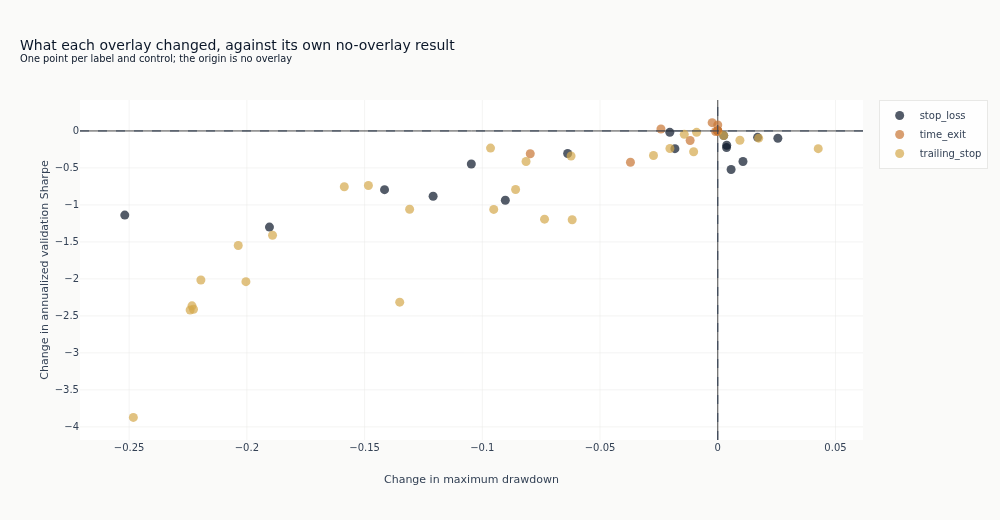

In [14]:
fig = go.Figure()
palette = {
    "stop_loss": COLORS["blue"],
    "trailing_stop": COLORS["amber"],
    "time_exit": COLORS["copper"],
}
for control_type in sorted(set(comparable.get_column("control_type"))):
    panel = comparable.filter(pl.col("control_type") == control_type)
    fig.add_trace(
        go.Scatter(
            x=panel.get_column("drawdown_change").to_list(),
            y=panel.get_column("sharpe_change").to_list(),
            mode="markers",
            name=control_type,
            text=panel.get_column("control").to_list(),
            marker={"size": 9, "color": palette.get(control_type, COLORS["slate"]), "opacity": 0.7},
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.add_vline(x=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_layout(
    title={
        "text": "What each overlay changed, against its own no-overlay result"
        "<br><sup>One point per label and control; the origin is no overlay</sup>",
        "x": 0.02,
        "xanchor": "left",
    },
    xaxis_title="Change in maximum drawdown",
    yaxis_title="Change in annualized validation Sharpe",
    height=520,
    width=1000,
)
show_plotly_with_alt(
    fig,
    "Scatter plot of the change in annualized validation Sharpe against the change in maximum "
    "drawdown, one point per label and declared risk control coloured by control type, with "
    "dashed lines through the origin marking the no-overlay result. Points spread on both sides of the horizontal line, "
    "so the controls do not separate from no overlay on Sharpe.",
)

## 5. The set the final choice is made from

One candidate set per label spanning all three stages: the equal-weight baseline, the allocation
results and the overlay results. [`19_strategy_analysis`](19_strategy_analysis.ipynb) selects one
configuration from it, so no overlay is eligible only by being an overlay - a label where no
control improved anything selects the configuration it already had.

The same admission rule as the previous stage applies, for the same reason: a result that did
not trade every validation fold is measured on a different period and cannot be ranked against
one that did. Here the rule catches a different failure than it did at the allocation stage - a
stop tight enough to close everything early sits out the rest of the span, and its Sharpe over
what it did trade would otherwise compete for the final selection.

`SUPERSEDES` names the generation of each set this run replaces, which the freeze refuses to do
implicitly. `19_strategy_analysis` resolves these four sets by name, so two live generations of
one name would leave it unable to say which comparison a result came from. It defaults to empty,
because a first run has nothing to replace and a set whose members are unchanged returns the
existing one without consulting it. Pass it only for a re-run that admits different members;
the error raised then names the predecessor hash to supply.

In [15]:
for label in labels:
    label_rows = keyed.filter(pl.col("label") == label)
    full = "+".join(str(fold) for fold in windows_by_label[label].get_column("fold").to_list())
    admitted = label_rows.filter(pl.col("traded_folds") == full)
    excluded = label_rows.height - admitted.height
    set_name = f"crypto-final-validation-{label}"
    if CANONICAL_RUN:
        members = study.backtests.freeze(
            results.filter(
                pl.col("backtest_hash").is_in(admitted.get_column("backtest_hash").implode())
            ),
            name=set_name,
            # Keyed by label, and also by the full set name, which is what the refusal prints.
            # Pasting back the name it names is the obvious thing to try, and it used to miss.
            # Resolved rather than offered: on a reader's clean clone there is no generation to
            # supersede and `create` refuses a first version that claims to replace one.
            supersedes=candidate_set_supersedes(
                study, name=set_name, declared=SUPERSEDES.get(set_name) or SUPERSEDES.get(label)
            ),
        )
        print(
            f"{members.name}: {len(members.members)} members traded folds {full}; "
            f"{excluded} excluded for trading fewer"
        )
    else:
        print(
            f"{set_name} (preview): {admitted.height} members traded folds {full}; "
            f"{excluded} excluded for trading fewer, not frozen"
        )

crypto-final-validation-fwd_ret_8h: 980 members traded folds 0+1; 0 excluded for trading fewer


crypto-final-validation-fwd_ret_24h: 920 members traded folds 0+1; 0 excluded for trading fewer


crypto-final-validation-fwd_dir_8h: 452 members traded folds 0+1; 0 excluded for trading fewer


crypto-final-validation-fwd_dir_8h_3c: 455 members traded folds 0+1; 0 excluded for trading fewer


## 6. What to notice

**An overlay is a second search, and the funnel narrows before it for that reason.** Fourteen
controls against one configuration is fourteen readings of the same validation year. Had the
stage run against the ten configurations the allocation stage started from, the highest Sharpe
in the grid would be the maximum of a hundred and forty draws, and the distance between that
maximum and the truth grows with the count whether or not any control helps.

**A stop pays twice on a funding-bearing instrument.** The exit is a trade, so it pays
commission and slippage at the declared schedule. The position it closes then stops settling
funding, and on perpetual futures that cash flow is a large part of what the strategy is there
to collect. A control that improves the price path and gives up the carry has not necessarily
improved anything.

**Drawdown and Sharpe do not move together.** A control can cut the worst peak-to-trough decline
and still lower the Sharpe, because it removes the recovery along with the decline. The chart
above puts the two on separate axes rather than resolving them into one number, since which one
matters is a question about the mandate rather than about the data.

**A calibrated threshold is a fitted parameter.** Reading a stop level off the same prices the
overlay is then scored on makes the level part of the search. The declared grid exists so the
search width is fixed in the configuration rather than chosen while the notebook runs, and that
is the property this stage would lose first if a threshold were fitted here.

**Known limitations.** Every control is applied uniformly to all nineteen contracts, so nothing
here says whether a stop that scales with a contract's own volatility would do better - that is
another parameter, and fitting it is the previous point. Portfolio-level controls are declared
nowhere for this case study, so the whole regime-control family is untested here. And every
number is measured on the validation folds at the declared cost schedule.

**Next**: [`16_costs`](16_costs.ipynb) prices the winner this stage names, and then
[`19_strategy_analysis`](19_strategy_analysis.ipynb) selects one configuration from
the set this notebook froze and reports what it did.